# Playing with nnInteractive

## Dependencies, Constants, and Helper Functions

In [1]:
import os
import torch
import random
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import math 
import numpy as np 
import pandas as pd

from pathlib import Path
from skimage.measure import regionprops
from skimage.draw import line

# from huggingface_hub import snapshot_download  # Install huggingface_hub if not already installed

# --- Download Trained Model Weights (~400MB) ---
REPO_ID = "nnInteractive/nnInteractive"
MODEL_NAME = "nnInteractive_v1.0"  # Updated models may be available in the future
DOWNLOAD_DIR = "/home/bhkuser/bhklab/kaitlyn/nnInteractive_test/model"  # Specify the download directory

# download_path = snapshot_download(
#     repo_id=REPO_ID,
#     allow_patterns=[f"{MODEL_NAME}/*"],
#     local_dir=DOWNLOAD_DIR
# )

# The model is now stored in DOWNLOAD_DIR/MODEL_NAME.

# --- Initialize Inference Session ---
from nnInteractive.nnInteractive.inference.inference_session import nnInteractiveInferenceSession

# Try to make reproducible 
torch.manual_seed(42) 
random.seed(42) 
np.random.seed(42)

nnUNet_raw is not defined and nnU-Net can only be used on data for which preprocessed files are already present on your system. nnU-Net cannot be used for experiment planning and preprocessing like this. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up properly.
nnUNet_preprocessed is not defined and nnU-Net can not be used for preprocessing or training. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up.
nnUNet_results is not defined and nnU-Net cannot be used for training or inference. If this is not intended behavior, please read documentation/setting_up_paths.md for information on how to set this up.


In [2]:
# TAKEN FROM: https://github.com/bhklab/medsam2-inference/blob/main/evaluate.py
# evaluate.py code putting here because notebook can't find module 
import numpy as np
import monai.metrics as met
import torch
import pandas as pd

class Evaluator:
    def __init__(
        self, 
        metrics: list[str] = [
            "volume_dice", 
            "jaccard", 
            "hausdorff", 
            "surface_distance",
            "surface_dice", 
            "panoptic_quality",
            "added_path_length", 
            "false_negative_volume", 
            "false_negative_path_length"
        ]
    ):
        self.metrics = metrics

    def __call__(self, preds: np.ndarray, targets: np.ndarray, spacing: tuple[float, float, float]) -> dict:
        results = {}
        
        for metric in self.metrics:
            match metric:
                case "volume_dice":
                    results[metric] = self._volume_dice(preds, targets)
                case "jaccard":
                    results[metric] = self._jaccard(preds, targets)
                case "hausdorff":
                    results[metric] = self._hausdorff(preds, targets, spacing)
                case "surface_distance":
                    results[metric] = self._surface_distance(preds, targets, spacing)
                case "surface_dice":
                    results[metric] = self._surface_dice(preds, targets, spacing)
                case "panoptic_quality":
                    results[metric] = self._panoptic_quality(preds, targets)
                case "added_path_length":
                    results[metric] = self._apl(preds, targets)
                case "false_negative_volume":
                    results[metric] = self._fnv(preds, targets)
                case "false_negative_path_length":
                    results[metric] = self._fnpl(preds, targets)
                case _:
                    raise ValueError(f"Metric {metric} not supported")
        
        return results  

    def summarize(self, results: pd.DataFrame) -> str:
        summary = "Summary of evaluation results:\n"

        for metric in self.metrics:
            if metric == "panoptic_quality":
                percent_positive = (results[metric] == 1.0).sum() / len(results[metric]) * 100
                summary += f"    {metric}: Percent positive: {percent_positive:.2f}%\n"
            else:
                summary += f"    {metric}: {results[metric].mean()}\n"
        return summary

    def _volume_dice(self, preds: np.ndarray, targets: np.ndarray) -> float:
        dc = (np.sum(preds[targets == 1]) * 2.0) / (np.sum(preds) + np.sum(targets))
        return dc
    
    def _jaccard(self, preds: np.ndarray, targets: np.ndarray) -> float:
        j = np.sum(preds[targets == 1]) / (np.sum(preds) + np.sum(targets) - np.sum(preds[targets == 1]))
        return j

    def _hausdorff(self, preds: np.ndarray, targets: np.ndarray, spacing: tuple[float, float, float]) -> float:
        preds = torch.from_numpy(preds).unsqueeze(0).unsqueeze(0)
        targets = torch.from_numpy(targets).unsqueeze(0).unsqueeze(0)
        h = met.compute_hausdorff_distance(preds, targets, percentile=95, include_background=False, spacing=spacing)
        return h[0].item()

    def _surface_distance(self, preds: np.ndarray, targets: np.ndarray, spacing: tuple[float, float, float]) -> float:
        preds = torch.from_numpy(preds).unsqueeze(0).unsqueeze(0)
        targets = torch.from_numpy(targets).unsqueeze(0).unsqueeze(0)
        s = met.compute_average_surface_distance(preds, targets, include_background=False, spacing=spacing)
        return s[0].item()
    
    def _surface_dice(self, preds: np.ndarray, targets: np.ndarray, spacing: tuple[float, float, float]) -> float:
        preds = torch.from_numpy(preds).unsqueeze(0).unsqueeze(0)
        targets = torch.from_numpy(targets).unsqueeze(0).unsqueeze(0)
        sd = met.compute_surface_dice(preds, targets, include_background=False, spacing=spacing, class_thresholds=[5]) #TODO: Continue research on finding appropriate class threshold. Set to 5 pixels for now. 
        return sd[0].item()
    
    def _panoptic_quality(self, preds: np.ndarray, targets: np.ndarray) -> float:
        preds = torch.from_numpy(preds).unsqueeze(0).unsqueeze(0)
        targets = torch.from_numpy(targets).unsqueeze(0).unsqueeze(0)
        pq = met.compute_panoptic_quality(preds, targets, output_confusion_matrix=True)
        return pq[0].item()

    def _apl(self, preds: np.ndarray, targets: np.ndarray) -> float:
        return AddedPathLength(preds, targets)
    
    def _fnv(self, preds: np.ndarray, targets: np.ndarray) -> float:
        return FalseNegativeVolume(preds, targets)
    
    def _fnpl(self, preds: np.ndarray, targets: np.ndarray) -> float:
        return FalseNegativePathLength(preds, targets)

"""
TAKEN FROM: https://github.com/kkiser1/Autosegmentation-Spatial-Similarity-Metrics/

Each function takes "auto" and "gt" arguments, which are respectively the autosegmentation and ground truth 
segmentation represented as three-dimensional NumPy arrays. The array dimensions should be the dimensions 
of the original image, and each array element should be 0 if its corresponding image pixel is not part of 
the segmentation or 1 if it is.
"""

def FalseNegativeVolume(auto, gt):
    '''
    Returns the false negative volume, in pixels
    
    Steps:
    1. Find pixels where the mask is present in gt but not in auto (wherever gt is 1 but auto is 0)
    2. Convert comparison from bool to int
    3. Compute # pixels
    '''
    
    fnv = (gt > auto).astype(int).sum()
    return fnv


def AddedPathLength(auto, gt):
    '''
    Returns the added path length, in pixels
    
    Steps:
    1. Find pixels at the edge of the mask for both auto and gt
    2. Count # pixels on the edge of gt that are not in the edge of auto
    '''
    
    # Check if auto and gt have same dimensions. If not, then raise a ValueError
    if auto.shape != gt.shape:
        raise ValueError('Shape of auto and gt must be identical!')

    # edge_auto has the pixels which are at the edge of the automated segmentation result
    edge_auto = getEdgeOfMask(auto)
    # edge_gt has the pixels which are at the edge of the ground truth segmentation
    edge_gt = getEdgeOfMask(gt)
    
    # Count # pixels on the edge of gt that are on not in the edge of auto
    apl = (edge_gt > edge_auto).astype(int).sum()
    
    return apl 


def FalseNegativePathLength(auto, gt):
    '''
    Returns the false negative path length, in pixels
    
    Steps:
    1. Find pixels at the edge of the mask for gt
    2. Count # pixels on the edge of gt that are not in the auto mask volume
    '''
    
    # Check if auto and gt have same dimensions. If not, then raise a ValueError
    if auto.shape != gt.shape:
        raise ValueError('Shape of auto and gt must be identical!')
    
    # edge_gt has the pixels which are at the edge of the ground truth segmentation
    edge_gt = getEdgeOfMask(gt)
    
    # Count # pixels where the edges in grount truth == 1 and auto == 0
    fnpl = (edge_gt > auto).astype(int).sum() 
    
    return fnpl

def getEdgeOfMask(mask):
    '''
    Computes and returns edge of a segmentation mask
    '''
    # edge has the pixels which are at the edge of the mask
    edge = np.zeros_like(mask)
    
    # mask_pixels has the pixels which are inside the mask of the automated segmentation result
    mask_pixels = np.where(mask > 0)

    for idx in range(0,mask_pixels[0].size):

        x = mask_pixels[0][idx]
        y = mask_pixels[1][idx]
        z = mask_pixels[2][idx]

        # Count # pixels in 3x3 neighborhood that are in the mask
        # If sum < 27, then (x, y, z) is on the edge of the mask
        if mask[x-1:x+2, y-1:y+2, z-1:z+2].sum() < 27:
            edge[x,y,z] = 1
            
    return edge

/home/bhkuser/bhklab/kaitlyn/bhklab-nninteractive/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def pos_neg_true_visual(image, 
                        mask_preds, 
                        gt_masks, 
                        window_level: int = 40, 
                        window_width: int = 400): 
    '''
    Visualization of the selected slices based on the ground truth, showing the true positive, false positive, and false
    negative areas within these slices. 

    Parameters
    ----------
    image: 
        The 3D array containing the original image data (assumes (z, x, y) order)
    mask_preds: 
        The array containing the predicted mask values (same shape as gt_masks). Assumes (z, x, y) order.
    gt_masks: 
        The array containing the ground truth mask values (same shape as mask_preds). Assumes (z, x, y) order.
    window_level: int 
        Window level for image visualiation. Set to 40 default. Is the abdominal window when the width is also left as default.
    window_width: int 
        The width of the window for image visualization. Set to 400 default. Is the abdominal window when the level is also left as default.
    '''
    #Calculate min and max HU for windowing 
    upper_val = window_level + window_width / 2 
    lower_val = window_level - window_width / 2 

    # Make the predicted mask a different number to represent a different colour 
    mask_alt = mask_preds * 2 

    # Add masks together so that false negative is 1, false positive is 2, and true positive is 3 
    comb_masks = mask_alt + gt_masks
    comb_masks = np.ma.masked_where(comb_masks == 0, comb_masks)

    # Find the first and last slices that have mask in them 
    gt_min, gt_max = find_first_last_slice(gt_masks)

    num_nonzero_slices = gt_max - gt_min + 1 # need to add one to get true number. e.g. slices 0 - 5 have non zero (inclusive), true answer is 6 slices, but subtraction only will yield 5
    # Check to see if there are more than 5 slices within the ground truth mask and adjust the subplot information accordingly 
    if num_nonzero_slices < 5: 
        if num_nonzero_slices == 1: 
            return 0 #If there was only one slice in the segmentation, this is redundant with the mid slice view plot.
        subplot_slices = num_nonzero_slices
        slices_to_plot = range(gt_min, gt_max + 1)
    else: 
        subplot_slices = 5
        slices_to_plot = [gt_min, gt_min + math.floor(num_nonzero_slices/4), gt_min + math.floor(num_nonzero_slices/2), gt_min + math.floor(num_nonzero_slices * 3 / 4), gt_max]
    
    print(slices_to_plot)
    fig, axes = plt.subplots(1, subplot_slices, figsize = (15, 3)) 

    # Create colour map for mask 
    colours = ['red', 'green', 'blue']
    boundaries = [1, 2, 3, 4]
    cmap = mcolors.ListedColormap(colours)
    norm = mcolors.BoundaryNorm(boundaries, cmap.N)

    # Make legend info 
    legend_elem = [mpatches.Patch(color = 'red', label = 'False Negative'), 
                mpatches.Patch(color = 'green', label = 'False Positive'), 
                mpatches.Patch(color = 'blue', label = 'True Positive')]
    counter = 0
    for i in slices_to_plot: 
        axes[counter].imshow(np.clip(image[i,:,:], lower_val, upper_val), cmap = 'gray') 
        axes[counter].imshow(comb_masks[i,:,:], cmap = cmap, norm = norm, interpolation = 'nearest', alpha = 0.6)
        axes[counter].axis("off")
        axes[counter].text(0.5, -0.1, f"Slice {i}", size = 11, ha ="center", transform = axes[counter].transAxes)
        counter += 1

        plt.tight_layout()

    fig.legend(handles = legend_elem, loc = 'lower right', bbox_to_anchor=(0.67, -0.15), ncol=3, frameon=False, fontsize=11)
    plt.show()

def find_first_last_slice(mask): 
    axes = tuple([i for i in range(mask.ndim) if i != 0])

    slices = mask.any(axis = axes) 

    nonzero_indices = np.where(slices)[0]

    first_slice = np.amin(nonzero_indices)
    last_slice = np.amax(nonzero_indices) 

    return first_slice, last_slice

def get_bbox_from_line(recist_arr): 
    '''ASSUMES IT'S IN Z, X, Y FORM'''
    # Find slice with the line in it 
    first, _ = find_first_last_slice(recist_arr)
    first = int(first)
    recist_slice = recist_arr[first]
    
    #Get properties of recist line 
    line_props = regionprops(recist_slice)[0]
    y_cent, x_cent = line_props.centroid
    maj_ax_len = line_props.axis_major_length

    #Get top left and bottom right corners of the bounding box 
    x_tl = x_cent - maj_ax_len / 2 
    y_tl = y_cent - maj_ax_len / 2 

    x_br = x_cent + maj_ax_len / 2 
    y_br = y_cent + maj_ax_len / 2

    # Note that the nnInteractive examples say the bounding box is in (x, y, z) order, but
    # in my experience, it actually expects (y, x, z) order 
    bbox = [[min(512, int(y_tl)), min(512, int(y_br))], [min(512, int(x_tl)), min(512, int(x_br))], [first, first + 1]]

    return bbox

def array_to_coords(data):
    for y, line in enumerate(data):
        for x, point in enumerate(line):
            if point == 1:
                yield(x, y)

def pad_bbox(box:np.array,
             mask:np.array, 
             padding:int,
             spacing:np.array = None
             ) -> np.array:
    # Get full image dimensions to keep padding within image size
    # D, H, W (z, y, x)
    mask_shape = mask.shape

    if spacing is not None: # Use the actual image spacing to calculate the padding
        # Check that spacing can be applied to this mask's bounding box dimensions
        if len(spacing) < len(mask_shape):
            spacing = spacing[0, len(mask_shape)]
        elif len(spacing) > len(mask_shape):
            message = "Spacing for padding has more dimensions than the mask image."
            raise ValueError(message)

        # calculate the number of voxels to pad based on the actual image spacing
        padding = np.round(padding / spacing)
    else:
        # Convert padding into an array with the same length as image dimensions
        # This matches the behaviour of the spacing option
        padding = padding * np.ones(len(mask_shape))
    
    pad_x_min = max(0, box[0] - padding[0])
    pad_y_min = max(0, box[1] - padding[1])
    # Handling 2D bounding box
    if len(box) == 4:
        mask_H, mask_W = mask_shape[0], mask_shape[1]
        pad_x_max = min(mask_W, box[2] + padding[0])
        pad_y_max = min(mask_H, box[3] + padding[1])

        padded_box = np.array([pad_x_min, pad_y_min,
                               pad_x_max, pad_y_max])

    # Handling 3D bounding box
    if len(box) == 6:
        mask_D, mask_H, mask_W = mask_shape[0], mask_shape[1], mask_shape[2]
        pad_z_min = max(0, box[2] - padding[2])
        pad_x_max = min(mask_W, box[3] + padding[0])
        pad_y_max = min(mask_H, box[4] + padding[1]) 
        pad_z_max = min(mask_D, box[5] + padding[2])
        
        padded_box = np.array([pad_x_min, pad_y_min, pad_z_min,
                               pad_x_max, pad_y_max, pad_z_max])

    return padded_box.astype(int)

def mask2D_to_bbox(gt2D:np.array, 
                   mask_path:Path, 
                   padding:int | None = None,
                   spacing:np.array = None
                   ) -> np.array:
    try:
        ## Old code 
        # y_indices, x_indices = np.where(gt2D > 0)
        # x_min, x_max = np.min(x_indices), np.max(x_indices)
        # y_min, y_max = np.min(y_indices), np.max(y_indices)
        # boxes = np.array([x_min, y_min, x_max, y_max])

        props = regionprops(gt2D)[0]
        y_cent, x_cent = props.centroid
        orientation = props.orientation
        semi_maj_axis_len = props.major_axis_length / 2

        x_start = x_cent - np.sin(orientation) * semi_maj_axis_len
        y_start = y_cent - np.cos(orientation) * semi_maj_axis_len

        x_end = x_cent + np.sin(orientation) * semi_maj_axis_len
        y_end = y_cent + np.cos(orientation) * semi_maj_axis_len

        boxes = np.array([x_start, y_start, x_end, y_end])

        if padding:
            boxes = pad_bbox(box = boxes,
                             mask = gt2D,
                             padding = padding,
                             spacing = spacing)
        
        return boxes.astype(int)
    
    except Exception as e:
        raise Exception(f'error {e} with file {mask_path} and sum of gts is {gt2D.sum()}')
    
def get_line_from_recist(recist_coords: np.array,
						 slice_number: int,
						 img_size: np.array):
	'''
	From the RECIST measurement coordinates, generate a line connecting both coordinates on the correct slice and return an np.ndarray the same shape as the image.
	Output to be compatible with the ['recist'] array of the .npz files needed for MedSAM2-RECIST.

	Parameters
	----------
	recist_coords: array
		A list of coordinates in [x1, y1, x2, y2] format that defines the RECIST measurement
	slice_number: int
		The slice that the measurement was taken on
	img_size: np.array
		The x, y, and z size of the image in [z_space, x_space, y_space] format

	Returns
	----------
	recist_arr: np.ndarray
		A binary array of the same shape as the image with the pixels of the line = 1
	'''
	# Check to see if RECIST coordinates are in string form and if so, convert to list
	if type(recist_coords) == str:
		just_coords = recist_coords.strip("[]")
		recist_coords = list(map(float, just_coords.split()))
		print(recist_coords)

	#Generate an array in the same size as the image filled with all zeros
	recist_arr = np.zeros((img_size[0], img_size[1], img_size[2]), dtype = int)

	#Round the coordinate values to their nearest integers
	coords_round = np.rint(recist_coords).astype(int)

	#Draw line using coordinates
	rr, cc = line(coords_round[0], coords_round[1], coords_round[2], coords_round[3])

	#Put line into the correct slice in the RECIST array of all zeros
	recist_arr[slice_number][cc, rr] = 1

	return recist_arr

def get_prompt_points(gt2D: np.array, 
                      spacing):
    '''  
    From the ground truth segmentation with the largest pixel area, generate the four 
    points that define the corners of a bounding box whose sides are orthogonal and 
    parallel to the RECIST line along with the midpoint of the RECIST line.

    Parameters
    ----------
    gt2D: np.array
        The ground truth segmentation at the largest area slice. Expects (z, x, y) format.
    spacing: 
        The spacing of the imaging used to create the ground truth segmentation. 
        To be used in case the sampled points are out of range. 

    Returns
    ----------
    negative_pts: np.array
        Holds the coordinate information for the four corners of the bounding box 
        and two points sampled along the minor axis with the length of a buffered
        semi major axis. In [x1, y1, x2, y2, x3, y3, x4, y4, x_min1, y_min1, x_min2, y_min2] 
        form. 
    center_pt: np.array
        Holds the coordinate information for the midpoint of the RECIST line in 
        [x_cent, y_cent] form.
    recist_pts: np.array
        Holds the information for the found RERECIST line in the form 
        [x_r1, y_r1, x_r2, y_r2]
    pts_25_75: np.array
        Holds the information for two points sampled along 25% and 75% of the length
        of the RECIST line
    major_axis_length: float 
        The length of the major axis. Returned for further calculations (e.g. bounding box prompt)
    '''
    try: 
        props = regionprops(gt2D)[0]
        y_cent, x_cent = props.centroid
        orientation = props.orientation
        semi_maj_axis_len = props.major_axis_length / 2

        x_r1 = x_cent - np.sin(orientation) * semi_maj_axis_len
        y_r1 = y_cent - np.cos(orientation) * semi_maj_axis_len

        x_r2 = x_cent + np.sin(orientation) * semi_maj_axis_len
        y_r2 = y_cent + np.cos(orientation) * semi_maj_axis_len

        # This is the point that is 25% of the way along the RECIST line from (x_r1, y_r1)
        x_r25 = x_cent - np.sin(orientation) * semi_maj_axis_len / 2 
        y_r25 = y_cent - np.cos(orientation) * semi_maj_axis_len / 2

        # This is the point that is 75% of the way long the RECIST line from (x_r1, y_r1) 
        x_r75 = x_cent + np.sin(orientation) * semi_maj_axis_len / 2
        y_r75 = y_cent + np.cos(orientation) * semi_maj_axis_len / 2

        # Coordinate pairs of points along minor axis but at the length of major axis (add a bit of buffer room since if sphere, these points would want to be included in the segmentation)
        x_min1 = min(spacing[1]-1, x_cent + np.cos(orientation) * semi_maj_axis_len * 1.2)
        y_min1 = min(spacing[2]-1, y_cent - np.sin(orientation) * semi_maj_axis_len * 1.2)

        x_min2 = min(spacing[1]-1, x_cent - np.cos(orientation) * semi_maj_axis_len * 1.2)
        y_min2 = min(spacing[2]-1, y_cent + np.sin(orientation) * semi_maj_axis_len * 1.2)

        # Corners of rotated bounding box
        x1 = min(spacing[1]-1, x_r1 + np.cos(orientation) * semi_maj_axis_len)
        y1 = min(spacing[2]-1, y_r1 - np.sin(orientation) * semi_maj_axis_len)

        x2 = min(spacing[1]-1, x_r1 - np.cos(orientation) * semi_maj_axis_len)
        y2 = min(spacing[2]-1, y_r1 + np.sin(orientation) * semi_maj_axis_len)

        x3 = min(spacing[1]-1, x_r2 + np.cos(orientation) * semi_maj_axis_len)
        y3 = min(spacing[2]-1, y_r2 - np.sin(orientation) * semi_maj_axis_len)

        x4 = min(spacing[1]-1, x_r2 - np.cos(orientation) * semi_maj_axis_len)
        y4 = min(spacing[2]-1, y_r2 + np.sin(orientation) * semi_maj_axis_len)

        negative_pts = np.array([x1, y1, x2, y2, x3, y3, x4, y4, x_min1, y_min1, x_min2, y_min2])
        
        recist_pts = np.array([x_r1, y_r1, x_r2, y_r2])

        center_pt = np.array([x_cent, y_cent])

        pts_25_75 = np.array([x_r25, y_r25, x_r75, y_r75])

    except Exception as e: 
         # Usually errors will arise here if there is an issue with region props calculation and the mask being too small to calculate anything from. 
         raise Exception(f'error {e} and sum of gts is {gt2D.sum()}')
    
    return negative_pts.astype(int), center_pt.astype(int), recist_pts.astype(int), pts_25_75.astype(int), props.major_axis_length 

# def get_prompt_points(gt2D: np.array):
#     '''  
#     From the ground truth segmentation with the largest pixel area, generate the four 
#     points that define the corners of a bounding box whose sides are orthogonal and 
#     parallel to the RECIST line along with the midpoint of the RECIST line.

#     Parameters
#     ----------
#     gt2D: np.array
#         The ground truth segmentation at the largest area slice

#     Returns
#     ----------
#     negative_pts: np.array
#         Holds the coordinate information for the four corners of the bounding box 
#         in [x1, y1, x2, y2, x3, y3, x4, y4] form. 
#     center_pt: np.array
#         Holds the coordinate information for the midpoint of the RECIST line in 
#         [x_cent, y_cent] form.
#     '''
#     try: 
#         props = regionprops(gt2D)[0]
#         y_cent, x_cent = props.centroid
#         orientation = props.orientation
#         semi_maj_axis_len = props.major_axis_length / 2

#         x_r1 = x_cent - np.sin(orientation) * semi_maj_axis_len
#         y_r1 = y_cent - np.cos(orientation) * semi_maj_axis_len

#         x_r2 = x_cent + np.sin(orientation) * semi_maj_axis_len
#         y_r2 = y_cent + np.cos(orientation) * semi_maj_axis_len

#         # This is the point that is 25% of the way along the RECIST line from (x_r1, y_r1)
#         x_r25 = x_cent - np.sin(orientation) * semi_maj_axis_len / 2 
#         y_r25 = y_cent - np.cos(orientation) * semi_maj_axis_len / 2

#         # This is the point that is 75% of the way long the RECIST line from (x_r1, y_r1) 
#         x_r75 = x_cent + np.sin(orientation) * semi_maj_axis_len / 2
#         y_r75 = y_cent + np.cos(orientation) * semi_maj_axis_len / 2

#         # Coordinate pairs of points along minor axis but at the length of major axis (add a bit of buffer room since if sphere, these points would want to be included in the segmentation)
#         x_min1 = x_cent + math.cos(orientation) * semi_maj_axis_len * 1.2
#         y_min1 = y_cent - math.sin(orientation) * semi_maj_axis_len * 1.2

#         x_min2 = x_cent - math.cos(orientation) * semi_maj_axis_len * 1.2
#         y_min2 = y_cent + math.sin(orientation) * semi_maj_axis_len * 1.2

#         # Corners of rotated bounding box
#         x1 = x_r1 + math.cos(orientation) * semi_maj_axis_len
#         y1 = y_r1 - math.sin(orientation) * semi_maj_axis_len

#         x2 = x_r1 - math.cos(orientation) * semi_maj_axis_len
#         y2 = y_r1 + math.sin(orientation) * semi_maj_axis_len

#         x3 = x_r2 + math.cos(orientation) * semi_maj_axis_len
#         y3 = y_r2 - math.sin(orientation) * semi_maj_axis_len

#         x4 = x_r2 - math.cos(orientation) * semi_maj_axis_len
#         y4 = y_r2 + math.sin(orientation) * semi_maj_axis_len

#         negative_pts = np.array([x1, y1, x2, y2, x3, y3, x4, y4, x_min1, y_min1, x_min2, y_min2])
        
#         recist_pts = np.array([x_r1, y_r1, x_r2, y_r2])

#         center_pt = np.array([x_cent, y_cent])

#         pt_25 = np.array([x_r25, y_r25])
#         pt_75 = np.array([x_r75, y_r75])

#     except Exception as e: 
#          raise Exception(f'error {e} and sum of gts is {gt2D.sum()}')
    
#     return negative_pts.astype(int), center_pt.astype(int), recist_pts.astype(int), pt_25.astype(int), pt_75.astype(int)

def pos_neg_true_visual(image, 
                        mask_preds, 
                        gt_masks, 
                        window_level: int = 40, 
                        window_width: int = 400): 
    '''
    Visualization of the selected slices based on the ground truth, showing the true positive, false positive, and false
    negative areas within these slices. 

    Parameters
    ----------
    image: 
        The 3D array containing the original image data (assumes (z, x, y) order)
    mask_preds: 
        The array containing the predicted mask values (same shape as gt_masks). Assumes (z, x, y) order.
    gt_masks: 
        The array containing the ground truth mask values (same shape as mask_preds). Assumes (z, x, y) order.
    window_level: int 
        Window level for image visualiation. Set to 40 default. Is the abdominal window when the width is also left as default.
    window_width: int 
        The width of the window for image visualization. Set to 400 default. Is the abdominal window when the level is also left as default.
    '''
    #Calculate min and max HU for windowing 
    upper_val = window_level + window_width / 2 
    lower_val = window_level - window_width / 2 

    # Make the predicted mask a different number to represent a different colour 
    mask_alt = mask_preds * 2 

    # Add masks together so that false negative is 1, false positive is 2, and true positive is 3 
    comb_masks = mask_alt + gt_masks
    comb_masks = np.ma.masked_where(comb_masks == 0, comb_masks)

    # Find the first and last slices that have mask in them 
    gt_min, gt_max = find_first_last_slice(gt_masks)

    num_nonzero_slices = gt_max - gt_min + 1 # need to add one to get true number. e.g. slices 0 - 5 have non zero (inclusive), true answer is 6 slices, but subtraction only will yield 5
    # Check to see if there are more than 5 slices within the ground truth mask and adjust the subplot information accordingly 
    if num_nonzero_slices < 5: 
        if num_nonzero_slices == 1: 
            return 0 #If there was only one slice in the segmentation, this is redundant with the mid slice view plot.
        subplot_slices = num_nonzero_slices
        slices_to_plot = range(gt_min, gt_max + 1)
    else: 
        subplot_slices = 5
        slices_to_plot = [gt_min, gt_min + math.floor(num_nonzero_slices/4), gt_min + math.floor(num_nonzero_slices/2), gt_min + math.floor(num_nonzero_slices * 3 / 4), gt_max]
    
    print(slices_to_plot)
    fig, axes = plt.subplots(1, subplot_slices, figsize = (15, 3)) 

    # Create colour map for mask 
    colours = ['red', 'green', 'blue']
    boundaries = [1, 2, 3, 4]
    cmap = mcolors.ListedColormap(colours)
    norm = mcolors.BoundaryNorm(boundaries, cmap.N)

    # Make legend info 
    legend_elem = [mpatches.Patch(color = 'red', label = 'False Negative'), 
                mpatches.Patch(color = 'green', label = 'False Positive'), 
                mpatches.Patch(color = 'blue', label = 'True Positive')]
    counter = 0
    for i in slices_to_plot: 
        axes[counter].imshow(np.clip(image[i,:,:], lower_val, upper_val), cmap = 'gray') 
        axes[counter].imshow(comb_masks[i,:,:], cmap = cmap, norm = norm, interpolation = 'nearest', alpha = 0.6)
        axes[counter].axis("off")
        axes[counter].text(0.5, -0.1, f"Slice {i}", size = 11, ha ="center", transform = axes[counter].transAxes)
        counter += 1

        plt.tight_layout()

    fig.legend(handles = legend_elem, loc = 'lower right', bbox_to_anchor=(0.67, -0.15), ncol=3, frameon=False, fontsize=11)

    plt.show()

def slice_visual(image, 
                mask_preds, 
                gt_masks, 
                slice_idx: int, 
                full_savepath: Path, 
                prompt: str): 
    '''
    Adjusted visualization from the inference_example_3D.ipynb example notebook that is in the BiomedParse repo. Saves a figure 
    showing the largest tumour area slice of the original image, the ground truth mask overlayed, and the predicted mask overlayed along 
    with the prompt used to create the mask as the legend. 

    Parameters
    ----------
    image: 
        The array containing the original image data (same shape as mask_preds and gt_masks)
    mask_preds: 
        The array containing the predicted mask values (same shape as the image and gt_masks) 
    gt_masks: 
        The array containing the ground truth mask values (same shape as the image and mask_preds) 
    slice_idx: int 
        The slice index to view
    full_savepath: Path
        Should contain where to save the path and what to call the file outputted
    prompt: str
        The prompt(s) that was/were used to create the mask
    '''
    slice_id = slice_idx
    slice_image = image[slice_id]
    slice_mask = mask_preds[slice_id]
    slice_gt   = gt_masks[slice_id]

    # 1) Compute the mapping
    unique_ids = np.unique(np.concatenate((slice_mask, slice_gt)))
    id_map = {orig_id: new_i for new_i, orig_id in enumerate(unique_ids)}

    slice_mask_mapped = np.vectorize(id_map.get)(slice_mask)
    slice_gt_mapped   = np.vectorize(id_map.get)(slice_gt)

    slice_mask_mapped = np.ma.masked_where(slice_mask_mapped == 0, slice_mask_mapped)
    slice_gt_mapped = np.ma.masked_where(slice_gt_mapped == 0, slice_gt_mapped)

    # 2) Which IDs to show (drop background=0)
    mask_ids = unique_ids[1:]

    # 3) Labels for legend (only if there is a text prompt)
    if prompt is not None:
        legends = [prompt[str(i)] for i in mask_ids if str(i) in prompt]
        mask_ids = [i for i in mask_ids if str(i) in prompt]

    # 4) Build a *discrete* colormap of size len(unique_ids)
    #    so that cmap(k) gives exactly the k-th color.
    cmap = plt.get_cmap('tab20', len(unique_ids)-1)

    # 5) Create handles using integer lookup into the discrete cmap
    if prompt is not None: 
        handles = [
            mpatches.Patch(color=cmap(id_map[i]-1), label=txt)
            for i, txt in zip(mask_ids, legends)
        ]

    # 6) Plot
    fig, axes = plt.subplots(1, 3, figsize=(8, 3))

    axes[0].imshow(slice_image, cmap="gray")
    axes[0].set_title("Original Image Slice")
    axes[0].axis("off")

    axes[1].imshow(slice_image, cmap='gray')
    axes[1].imshow(slice_gt_mapped, cmap=cmap, interpolation='nearest', alpha = 0.6)
    axes[1].set_title("Ground Truth Masks")
    axes[1].axis("off")

    axes[2].imshow(slice_image, cmap='gray')
    axes[2].imshow(slice_mask_mapped, cmap=cmap, interpolation='nearest', alpha = 0.6)
    axes[2].set_title("Predicted Masks")
    axes[2].axis("off")

    # 7) Shared legend below, single column
    if prompt is not None: 
        fig.legend(handles, legends, loc='lower center', bbox_to_anchor=(0.29, -0.15), ncol=1, frameon=False, fontsize=11)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0)
    
    plt.show()

def transform_prompt_points(negative_pts: np.array,
                            recist_pts: np.array, 
                            pts_25_75: np.array, 
                            max_area_slice: int, 
                            img_shape: list):
    '''   
    From the points extracted from the current imaging pair, get them into nnInteractive-ready form. 

    Parameters
    ----------
    negative_pts: np.array
        Holds the coordinate information for the four corners of the bounding box 
        and two points sampled along the minor axis with the length of a buffered
        semi major axis. In [x1, y1, x2, y2, x3, y3, x4, y4, x_min1, y_min1, x_min2, y_min2] 
        form. 
    center_pt: np.array
        Holds the coordinate information for the midpoint of the RECIST line in 
        [x_cent, y_cent] form.
    recist_pts: np.array
        Holds the information for the found RERECIST line in the form 
        [x_r1, y_r1, x_r2, y_r2]
    pts_25_75: np.array
        Holds the information for two points sampled along 25% and 75% of the length
        of the RECIST line 
    max_area_slice: int
        The index of the slice with the largest tumour area.
    img_shape: list 
        The shape of the imaging array. To be used to make the RERECIST scribble. 

    Returns
    ----------
    RERECIST_SCRIB: np.ndarray 
        A 3D array with the RERECIST line on the maximum tumour area slice in (x, y, z) form. 
    BBOX_ROTATED: list 
        List of tuples representing the four corners of the bounding box of the rotated ellipse encompassing the tumour
        NOTE: All points in (y, x, z) form. 
    MIN_AX_PTS: list
        List of tuples representing the two points sampled along the minor axis with length 1.2*major_axis_length/2
        from the center point. NOTE: All points in (y, x, z) form.
    PTS_25_75: list 
        List of tuples representing two points sampled along 25% length and 75% length of the RERECIST line. 
        NOTE: All points in (y, x, z) form.
    ''' 
    # Get RERECIST scribble 
    recist_line = get_line_from_recist(recist_coords = recist_pts, slice_number = max_area_slice, img_size = img_shape)
    RERECIST_SCRIB = recist_line.transpose(1, 2, 0)

    # Get the rotated bounding box corners 
    BBOX_ROTATED = [(negative_pts[1], negative_pts[0], max_area_slice), 
                    (negative_pts[3], negative_pts[2], max_area_slice), 
                    (negative_pts[5], negative_pts[4], max_area_slice), 
                    (negative_pts[7], negative_pts[6], max_area_slice)]
    
    # Get minor axis sampled points 
    MIN_AX_PTS = [(negative_pts[9], negative_pts[8], max_area_slice), 
                  (negative_pts[11], negative_pts[10], max_area_slice)]
    
    # Get two points sampled along the RERECIST line 
    PTS_25_75 = [(pts_25_75[1], pts_25_75[0], max_area_slice), 
                 (pts_25_75[3], pts_25_75[2], max_area_slice)]
    
    return RERECIST_SCRIB, BBOX_ROTATED, MIN_AX_PTS, PTS_25_75

## Initiate Session

In [ ]:
### Notes: do_autozoom=True results in non-deterministic segmentations which are visibly noticeable. 
### To get repeatable segmentations, set do_autozoom=False. Performance will likely drop this way though

session = nnInteractiveInferenceSession(
    device=torch.device("cpu"),  # Set inference device
    use_torch_compile=False,  # Experimental: Not tested yet
    verbose=False,
    torch_n_threads=os.cpu_count(),  # Use available CPU cores
    do_autozoom=True,  # Enables AutoZoom for better patching
    use_pinned_memory=True,  # Optimizes GPU memory transfers
)

In [ ]:
# Load the trained model

model_path = os.path.join(DOWNLOAD_DIR, MODEL_NAME)
session.initialize_from_trained_model_folder(model_path)

Unable to locate trainer class nnInteractiveTrainer_stub in nnInteractive.trainer. Please place it there (in any .py file)!
Attempting to use default nnInteractiveTrainer_stub. If you encounter errors, this is where you need to look!


## Test Inference

In [ ]:
# --- Load Input Image (Example with SimpleITK) ---
# DO NOT preprocess the image in any way. Give it to nnInteractive as it is! DO NOT apply level window, DO NOT normalize 
# intensities and never ever convert an image with higher precision (float32, uint16, etc) to uint8!
# The ONLY instance where some preprocesing makes sense is if your original image is too large to be reasonably used. 
# This may be the case, for example, for some microCT images. In this case you can consider downsampling.

# input_image = sitk.ReadImage("/home/bhkuser/bhklab/kaitlyn/recist-vs-reality/data/procdata/Abdomen/TCIA_CPTAC-CCRCC/images/mit_CPTAC-CCRCC/C3N-00194_0035/CT_85226559/CT.nii.gz")
# img = sitk.GetArrayFromImage(input_image)[None]  # Ensure shape (1, x, y, z)

#Testing with input image from npz
#From H4H run
# npz_info = np.load('/home/bhkuser/bhklab/kaitlyn/bhklab-nninteractive/C3N-00494_0033_RTSTRUCT_812952.npz')

#From lab server
npz_info = np.load('/home/bhkuser/bhklab/kaitlyn/recist-vs-reality/data/procdata/Abdomen/TCIA_CPTAC-CCRCC/images/npz_TCIA_CPTAC-CCRCC/C3N-00494_0065_RTSTRUCT_958818.4_0.npz')

img = npz_info['imgs'][None]
# # Testing windowing: COMMENT OUT IF YOU DO NOT WANT THE IMAGE WINDOWED
# img = np.clip(img, -145, 215)

img = img.transpose(0, 2, 3, 1) # make sure that shape is transformed from (1, z, x, y) to (1, x, y, z)
recist_scrib = npz_info['recist'].transpose(1, 2, 0)

# Make bounding box
bbox = get_bbox_from_line(recist_arr = npz_info['recist'])

# Validate input dimensions
if img.ndim != 4:
    raise ValueError("Input image must be 4D with shape (1, x, y, z)")

session.set_image(img)

# --- Define Output Buffer ---
target_tensor = torch.zeros(img.shape[1:], dtype=torch.uint8)  # Must be 3D (x, y, z)
session.set_target_buffer(target_tensor)

NameError: name 'session' is not defined

In [ ]:
bbox

[[276, 309], [204, 236], [68, 69]]

### Coordinate-Based Segmentation

In [ ]:
# --- Interacting with the Model ---
# Interactions can be freely chained and mixed in any order. Each interaction refines the segmentation.
# The model updates the segmentation mask in the target buffer after every interaction.
POINT_COORDINATES = (161, 231, 20)
# Example: Add a **positive** point interaction
# POINT_COORDINATES should be a tuple (x, y, z) specifying the point location.
session.add_point_interaction(POINT_COORDINATES, include_interaction=True)

Added new point interaction: center 1, scale [[161, 231, 20]]
Took 16.635 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 16.643s


In [ ]:
# --- Retrieve Results ---
# The target buffer holds the segmentation result.
results = session.target_buffer.clone()
cmap = plt.get_cmap('tab20', 0)

# Print the number of mask points created 
print(np.count_nonzero(results.numpy()))

# Plot resulting image 
plt.figure(figsize=(8,8))
plt.imshow(img[0,:,:,20], cmap = "gray")
plt.imshow(results[:, :, 20].numpy(), cmap = cmap, alpha = 0.6, interpolation = 'nearest')
plt.tight_layout()
plt.show()

# Reset target buffer
target_tensor = torch.zeros(img.shape[1:], dtype=torch.uint8)  # Must be 3D (x, y, z)
session.set_target_buffer(target_tensor)

57


In [ ]:
# Example: Add a **negative** point interaction
# To make any interaction negative set include_interaction=False
session.add_point_interaction(POINT_COORDINATES, include_interaction=False)

Added new point interaction: center 1, scale [[161, 231, 20]]
Took 15.941 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 15.953s


### Using Bounding Box

In [ ]:
# Reset target buffer and interactions
session.set_target_buffer(torch.zeros(img.shape[1:], dtype=torch.uint8))
session.reset_interactions()
# Example: Add a bounding box interaction
# BBOX_COORDINATES must be specified as [[x1, x2], [y1, y2], [z1, z2]] (half-open intervals).
# Note: nnInteractive pre-trained models currently only support **2D bounding boxes**.
# This means that **one dimension must be [d, d+1]** to indicate a single slice.
# BBOX_COORDINATES = [[212, 381], [293, 425], [29, 30]] #These are actually [[y1, y2], [x1, x2], [z1, z2]]??

# Example of a 2D bounding box in the axial plane (XY slice at depth Z)
# BBOX_COORDINATES = [[30, 80], [40, 100], [10, 11]]  # X: 30-80, Y: 40-100, Z: slice 10

session.add_bbox_interaction(bbox, include_interaction=True)

# --- Retrieve Results ---
# The target buffer holds the segmentation result.
results = session.target_buffer.clone()
results = np.ma.masked_where(results.numpy() == 0, results)

Added new bbox interaction: center 1, scale [[292, 220, 68]]
Took 15.715 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 15.726s


7614


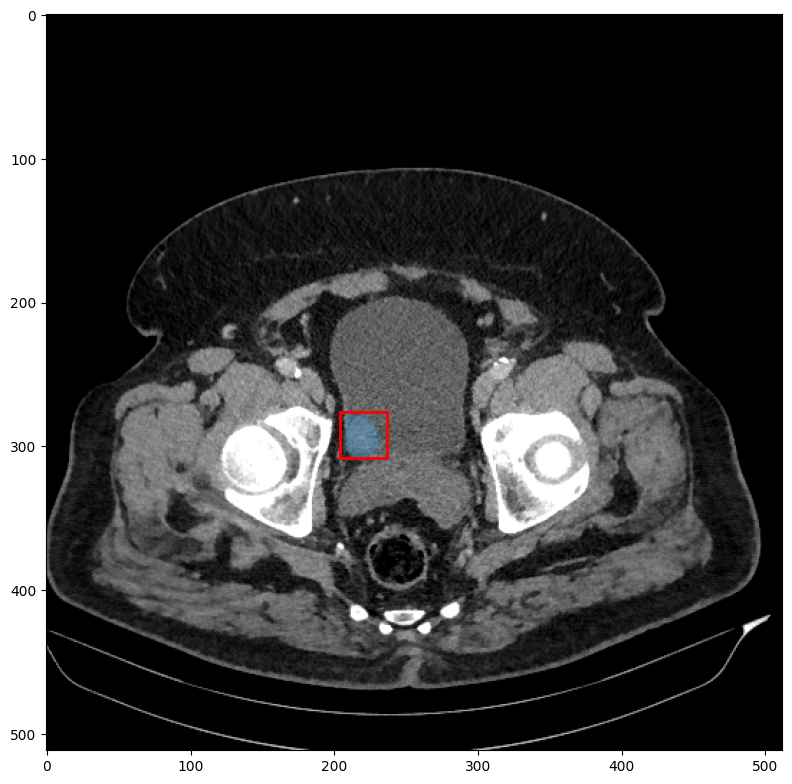

In [ ]:
%matplotlib inline 
cmap = plt.get_cmap('tab20', 1)

# Print the number of mask points created 
print(np.count_nonzero(results))
bbox = mpatches.Rectangle((204, 276), 33, 32, linewidth = 1, edgecolor='red', facecolor=None, fill = False)

# Plot resulting image 
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(img[0,:,:,68], cmap = "gray")
ax.imshow(results[:, :, 68], cmap = cmap, alpha = 0.4, interpolation = 'nearest')
ax.add_patch(bbox)
plt.tight_layout() 
plt.show()

# Reset target buffer
target_tensor = torch.zeros(img.shape[1:], dtype=torch.uint8)  # Must be 3D (x, y, z)
session.set_target_buffer(target_tensor)

[np.int64(62), np.int64(66), np.int64(70), np.int64(74), np.int64(78)]


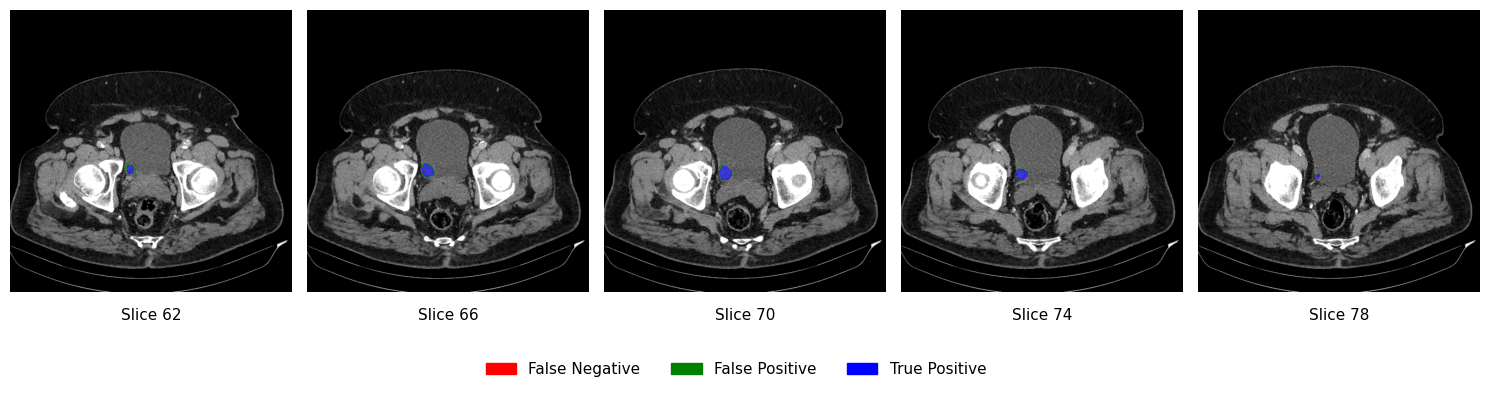

In [ ]:
# Making the positive negative visualization 
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches 
import math 
%matplotlib inline
# Make the predicted mask a different number to represent a different colour 
mask_alt = results * 2 

# Add masks together so that false negative is 1, false positive is 2, and true positive is 3 
comb_masks_arr = mask_alt + npz_info['gts'].transpose(1, 2, 0)
comb_masks = np.ma.masked_where(comb_masks_arr == 0, comb_masks_arr)

# Find the first and last slices that have mask in them 
gt_min, gt_max = find_first_last_slice(npz_info['gts'])
# pred_min, pred_max = find_first_last_slice(mask_preds) 

num_nonzero_slices = gt_max - gt_min + 1 # need to add one to get true number. e.g. slices 0 - 5 have non zero (inclusive), true answer is 6 slices, but subtraction only will yield 5
# Check to see if there are more than 5 slices within the ground truth mask and adjust the subplot information accordingly 
if num_nonzero_slices < 5: 
    subplot_slices = num_nonzero_slices
else: 
    subplot_slices = 5

# slices_to_plot = [pred_min, gt_min, gt_min + math.floor(num_nonzero_slices/4), gt_min + math.floor(num_nonzero_slices/2), gt_min + math.floor(num_nonzero_slices * 3 / 4), gt_max, pred_max]
slices_to_plot = [gt_min, gt_min + math.floor(num_nonzero_slices/4), gt_min + math.floor(num_nonzero_slices/2), gt_min + math.floor(num_nonzero_slices * 3 / 4), gt_max]
print(slices_to_plot)

# Get info for plotting bbox 
xmin = bbox[0][0]
ymin = bbox[1][0]
width = abs(xmin - bbox[0][1])
height = abs(ymin - bbox[1][1])

# Plot the five most middle slices to the segmentation and overlay them on top of the original image
fig, axes = plt.subplots(1, 5, figsize = (15, 4)) 

# Create colour map for mask 
colours = ['red', 'green', 'blue']
boundaries = [1, 2, 3, 4]
cmap = mcolors.ListedColormap(colours)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

# Make bounding box
bbox_plot = mpatches.Rectangle((xmin, ymin), width, height, linewidth = 1, edgecolor='r', facecolor='none') 

# Make legend info 
legend_elem = [mpatches.Patch(color = 'red', label = 'False Negative'), 
               mpatches.Patch(color = 'green', label = 'False Positive'), 
               mpatches.Patch(color = 'blue', label = 'True Positive')]
counter = 0
for i in slices_to_plot: 
    axes[counter].imshow(img[0,:,:,i], cmap = 'gray') 
    axes[counter].imshow(comb_masks[:,:,i], cmap = cmap, norm = norm, interpolation = 'nearest', alpha = 0.6)
    axes[counter].axis("off")
    axes[counter].text(0.5, -0.1, f"Slice {i}", size =11, ha="center", transform = axes[counter].transAxes)
    counter += 1
    plt.tight_layout()

fig.legend(handles = legend_elem, loc = 'lower right', bbox_to_anchor=(0.67, -0.10), ncol=3, frameon=False, fontsize=11)
plt.show()

### Scribble (AKA Lines)

In [ ]:
# Example: Add a scribble interaction
# - A 3D image of the same shape as img where one slice (any axis-aligned orientation) contains a hand-drawn scribble.
# - Background must be 0, and scribble must be 1.
# - Use session.preferred_scribble_thickness for optimal results.

# Reset target buffer and interactions
session.set_target_buffer(torch.zeros(img.shape[1:], dtype=torch.uint8))
session.reset_interactions()

session.add_scribble_interaction(recist_scrib, include_interaction=True)

# --- Retrieve Results ---
# The target buffer holds the segmentation result.
results = session.target_buffer.clone()
results = np.ma.masked_where(results.numpy() == 0, results)

Added new image interaction: scale 1, center [[294, 221, 68]]
Took 17.3 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 17.309s


6245


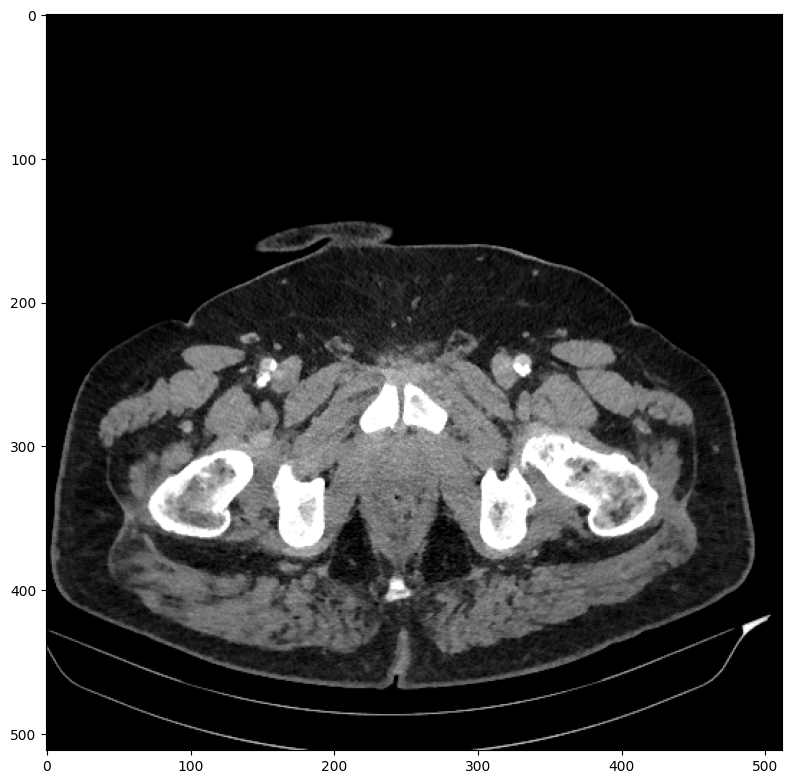

In [ ]:
%matplotlib inline 
cmap = plt.get_cmap('tab20', 1)

# Print the number of mask points created 
print(np.count_nonzero(results))
# bbox = patches.Rectangle((293, 212), 132, 169, linewidth = 2, edgecolor='red', facecolor=None)

# Plot resulting image 
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(np.clip(img[0,:,:,35],-135, 215), cmap = "gray")
ax.imshow(results[:, :, 35], cmap = cmap, alpha = 0.4, interpolation = 'nearest')
# ax.add_patch(bbox)
plt.tight_layout() 
plt.show()

# Reset target buffer
target_tensor = torch.zeros(img.shape[1:], dtype=torch.uint8)  # Must be 3D (x, y, z)
session.set_target_buffer(target_tensor)

60 78
[np.int64(62), np.int64(66), np.int64(70), np.int64(74), np.int64(78)]


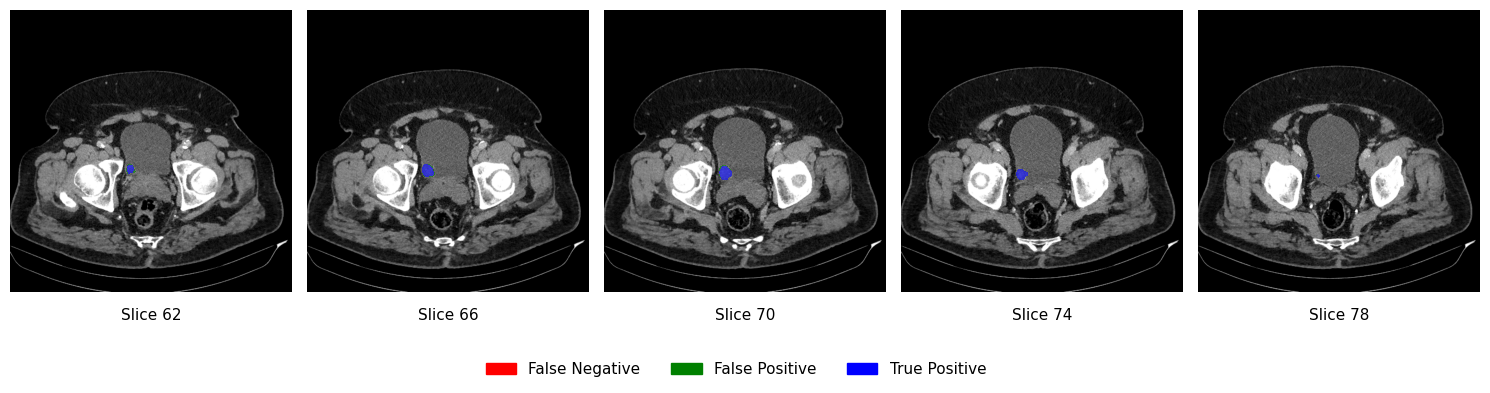

In [ ]:
# Making the positive negative visualization 
%matplotlib inline
# Make the predicted mask a different number to represent a different colour 
mask_alt = results * 2 

# Add masks together so that false negative is 1, false positive is 2, and true positive is 3 
comb_masks_arr = mask_alt + npz_info['gts'].transpose(1, 2, 0)
comb_masks = np.ma.masked_where(comb_masks_arr == 0, comb_masks_arr)

# Find the first and last slices that have mask in them 
gt_min, gt_max = find_first_last_slice(npz_info['gts'])
pred_min, pred_max = find_first_last_slice(results.transpose(2, 0, 1))
print(pred_min, pred_max)
# pred_min, pred_max = find_first_last_slice(mask_preds) 

num_nonzero_slices = gt_max - gt_min + 1 # need to add one to get true number. e.g. slices 0 - 5 have non zero (inclusive), true answer is 6 slices, but subtraction only will yield 5
# Check to see if there are more than 5 slices within the ground truth mask and adjust the subplot information accordingly 
if num_nonzero_slices < 5: 
    subplot_slices = num_nonzero_slices
else: 
    subplot_slices = 5

# slices_to_plot = [pred_min, gt_min, gt_min + math.floor(num_nonzero_slices/4), gt_min + math.floor(num_nonzero_slices/2), gt_min + math.floor(num_nonzero_slices * 3 / 4), gt_max, pred_max]
slices_to_plot = [gt_min, gt_min + math.floor(num_nonzero_slices/4), gt_min + math.floor(num_nonzero_slices/2), gt_min + math.floor(num_nonzero_slices * 3 / 4), gt_max]
print(slices_to_plot)
# Plot the five most middle slices to the segmentation and overlay them on top of the original image
fig, axes = plt.subplots(1, 5, figsize = (15, 4)) 

# Create colour map for mask 
colours = ['red', 'green', 'blue']
boundaries = [1, 2, 3, 4]
cmap = mcolors.ListedColormap(colours)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

# Make legend info 
legend_elem = [mpatches.Patch(color = 'red', label = 'False Negative'), 
               mpatches.Patch(color = 'green', label = 'False Positive'), 
               mpatches.Patch(color = 'blue', label = 'True Positive')]
counter = 0
for i in slices_to_plot: 
    axes[counter].imshow(np.clip(img[0,:,:,i], -135, 215), cmap = 'gray') 
    axes[counter].imshow(comb_masks[:,:,i], cmap = cmap, norm = norm, interpolation = 'nearest', alpha = 0.6)
    axes[counter].axis("off")
    axes[counter].text(0.5, -0.1, f"Slice {i}", size =11, ha="center", transform = axes[counter].transAxes)
    counter += 1
    plt.tight_layout()

fig.legend(handles = legend_elem, loc = 'lower right', bbox_to_anchor=(0.67, -0.10), ncol=3, frameon=False, fontsize=11)
plt.show()

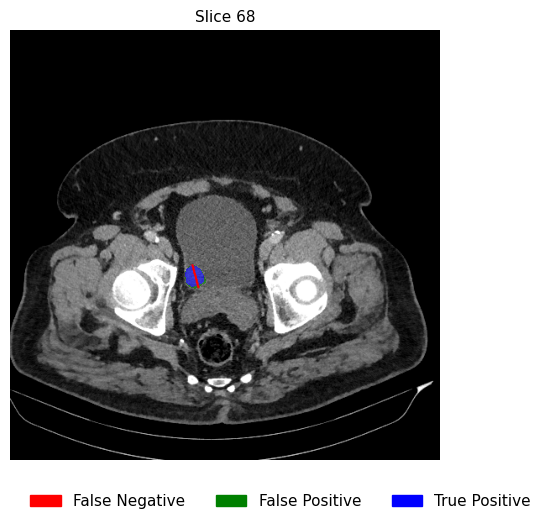

In [ ]:
# Plot the RERECIST line overlaying the image slice that it's on. 

slice_rere, _ = find_first_last_slice(npz_info['recist'])

line_data = list(array_to_coords(npz_info['recist'].transpose(1, 2, 0)[:, :, slice_rere]))
x, y = zip(*line_data)

fig = plt.figure()

# Create colour map for mask 
colours = ['red', 'green', 'blue']
boundaries = [1, 2, 3, 4]
cmap = mcolors.ListedColormap(colours)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

# Make legend info 
legend_elem = [mpatches.Patch(color = 'red', label = 'False Negative'), 
               mpatches.Patch(color = 'green', label = 'False Positive'), 
               mpatches.Patch(color = 'blue', label = 'True Positive')]

plt.imshow(np.clip(img[0,:,:,slice_rere], -135, 215), cmap = 'gray') 
plt.imshow(comb_masks[:,:,slice_rere], cmap = cmap, norm = norm, interpolation = 'nearest', alpha = 0.6)
plt.plot(x, y, 'r')
plt.axis("off")
plt.title(f"Slice {slice_rere}", size =11)
counter += 1
plt.tight_layout()

fig.legend(handles = legend_elem, loc = 'lower right', bbox_to_anchor=(1.0, -0.10), ncol=3, frameon=False, fontsize=11)
plt.show()

### Combining Scribble and Bounding Box 

In [ ]:
# Reset target buffer and interactions
session.set_target_buffer(torch.zeros(img.shape[1:], dtype=torch.uint8))
session.reset_interactions()

# Add scribble and bounding box interactions 
session.add_bbox_interaction(bbox_coords = bbox, 
                             include_interaction = True)
session.add_scribble_interaction(recist_scrib, include_interaction=True)

# --- Retrieve Results ---
# The target buffer holds the segmentation result.
results = session.target_buffer.clone()
results = np.ma.masked_where(results.numpy() == 0, results)

Added new bbox interaction: center 1, scale [[292, 220, 68]]
Took 15.722 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 15.73s
Added new image interaction: scale 1, center [[294, 221, 68]]
Took 15.197 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 15.202s


In [ ]:
# Making the positive negative visualization 
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches 
import math 
%matplotlib inline
# Make the predicted mask a different number to represent a different colour 
mask_alt = results * 2 

# Add masks together so that false negative is 1, false positive is 2, and true positive is 3 
comb_masks_arr = mask_alt + npz_info['gts'].transpose(1, 2, 0)
comb_masks = np.ma.masked_where(comb_masks_arr == 0, comb_masks_arr)

# Find the first and last slices that have mask in them 
gt_min, gt_max = find_first_last_slice(npz_info['gts'])
# pred_min, pred_max = find_first_last_slice(mask_preds) 

num_nonzero_slices = gt_max - gt_min + 1 # need to add one to get true number. e.g. slices 0 - 5 have non zero (inclusive), true answer is 6 slices, but subtraction only will yield 5
# Check to see if there are more than 5 slices within the ground truth mask and adjust the subplot information accordingly 
if num_nonzero_slices < 5: 
    subplot_slices = num_nonzero_slices
else: 
    subplot_slices = 5

# slices_to_plot = [pred_min, gt_min, gt_min + math.floor(num_nonzero_slices/4), gt_min + math.floor(num_nonzero_slices/2), gt_min + math.floor(num_nonzero_slices * 3 / 4), gt_max, pred_max]
slices_to_plot = [gt_min, gt_min + math.floor(num_nonzero_slices/4), gt_min + math.floor(num_nonzero_slices/2), gt_min + math.floor(num_nonzero_slices * 3 / 4), gt_max]
print(slices_to_plot)

# Get info for plotting bbox 
xmin = bbox[0][0]
ymin = bbox[1][0]
width = abs(xmin - bbox[0][1])
height = abs(ymin - bbox[1][1])

# Plot the five most middle slices to the segmentation and overlay them on top of the original image
fig, axes = plt.subplots(1, 5, figsize = (15, 4)) 

# Create colour map for mask 
colours = ['red', 'green', 'blue']
boundaries = [1, 2, 3, 4]
cmap = mcolors.ListedColormap(colours)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

# Make bounding box
bbox_plot = mpatches.Rectangle((xmin, ymin), width, height, linewidth = 1, edgecolor='r', facecolor='none') 

# Make legend info 
legend_elem = [mpatches.Patch(color = 'red', label = 'False Negative'), 
               mpatches.Patch(color = 'green', label = 'False Positive'), 
               mpatches.Patch(color = 'blue', label = 'True Positive')]
counter = 0
for i in slices_to_plot: 
    axes[counter].imshow(img[0,:,:,i], cmap = 'gray') 
    axes[counter].imshow(comb_masks[:,:,i], cmap = cmap, norm = norm, interpolation = 'nearest', alpha = 0.6)
    axes[counter].axis("off")
    axes[counter].text(0.5, -0.1, f"Slice {i}", size =11, ha="center", transform = axes[counter].transAxes)
    counter += 1
    plt.tight_layout()

fig.legend(handles = legend_elem, loc = 'lower right', bbox_to_anchor=(0.67, -0.10), ncol=3, frameon=False, fontsize=11)
plt.show()

NameError: name 'results' is not defined

## Iterative Point-Based Approach through Z-Axis

In [6]:
## Load in data 
# img_data = sitk.ReadImage("/home/bhkuser/bhklab/kaitlyn/bhklab-nninteractive/data/procdata/MultiSite/CVPR_LesionLocator/images/Baseline/LesionLocator_0001/CT.nii.gz")
# mask_data = sitk.ReadImage("/home/bhkuser/bhklab/kaitlyn/bhklab-nninteractive/data/procdata/MultiSite/CVPR_LesionLocator/images/Baseline/LesionLocator_0001/mask_1.nii.gz")

# img_arr = sitk.GetArrayFromImage(img_data) 
# mask_arr = sitk.GetArrayFromImage(mask_data) 

%matplotlib inline
npz_info = np.load('/home/bhkuser/bhklab/kaitlyn/recist-vs-reality/data/procdata/Abdomen/TCIA_CPTAC-CCRCC/bbox_gen/C3N-00194_0036_RTSTRUCT_855932.4_2.npz')

img_arr = npz_info['imgs']
mask_arr = npz_info['gts']
## Get the RERECIST line data 
slice_sums = np.sum(mask_arr, axis = (1, 2)) # Get the pixel area of each slice 
max_area_slice = np.argmax(slice_sums) # Get the slice with the largest pixel area 

# Find the center point of the RECIST line and the corners of the square centered around RECIST line midpoint 
# whose sides would be parallel and orthogonal to the RECIST line. 
negative_points, center_point, recist_points, pts_25_75, length = get_prompt_points(gt2D = mask_arr[max_area_slice], 
                                                                            spacing = img_arr.shape) 
RERECIST_SCRIB, BBOX_ROTATED, MIN_AX_PTS, PTS_25_75 = transform_prompt_points(negative_pts = negative_points, 
                                                                                  recist_pts = recist_points, 
                                                                                  pts_25_75 = pts_25_75, 
                                                                                  max_area_slice = max_area_slice, 
                                                                                  img_shape = mask_arr.shape)
recist_line = get_line_from_recist(recist_coords = recist_points, slice_number = max_area_slice, img_size = img_arr.shape)

In [9]:
MIN_AX_PTS

[(np.int64(288), np.int64(448), np.int64(95)),
 (np.int64(288), np.int64(255), np.int64(95))]

In [ ]:

## Initiate session and use the middle of the RERECIST line as the first input 
session = nnInteractiveInferenceSession(
    device=torch.device("cpu"),  # Set inference device
    use_torch_compile=False,  # Experimental: Not tested yet
    verbose=False,
    torch_n_threads=os.cpu_count(),  # Use available CPU cores
    do_autozoom=True,  # Enables AutoZoom for better patching
    use_pinned_memory=True,  # Optimizes GPU memory transfers
)

model_path = os.path.join(DOWNLOAD_DIR, MODEL_NAME)
session.initialize_from_trained_model_folder(model_path)

# Transform imaging to be compatible with nnInteractive 
img = img_arr[None].transpose(0, 2, 3, 1) # make sure that shape is transformed from (1, z, x, y) to (1, x, y, z)

# Validate input dimensions
if img.ndim != 4:
    raise ValueError("Input image must be 4D with shape (1, x, y, z)")

session.set_image(img)

# --- Define Output Buffer ---
target_tensor = torch.zeros(img.shape[1:], dtype=torch.uint8)  # Must be 3D (x, y, z)
session.set_target_buffer(target_tensor)

# Enter center point coordinate as first prompt 
CENTER_POINT = (center_point[1], center_point[0], max_area_slice) # In y, x, z form
POINT_25 = (point_25[1], point_25[0], max_area_slice)
POINT_75 = (point_75[1], point_75[0], max_area_slice)
# RECIST_POINT1 = (recist_points[1], recist_points[0], max_area_slice)
# RECIST_POINT2 = (recist_points[3], recist_points[2], max_area_slice)

# session.add_scribble_interaction(recist_line.transpose(1, 2, 0), include_interaction=True)
# session.preferred_scribble_thickness
# session.add_point_interaction(CENTER_POINT, include_interaction=True)
# session.add_point_interaction(RECIST_POINT1, include_interaction=True) 
# session.add_point_interaction(RECIST_POINT2, include_interaction=True)
session.add_point_interaction(POINT_25, include_interaction=True)
session.add_point_interaction(POINT_75, include_interaction=True)

# Transform results back to z, x, y form 
results_xyz = session.target_buffer.clone()
results_zxy = results_xyz.cpu().numpy().transpose(2, 0, 1)

## Visualize first input and evaluate performance 
# Evaluate performance
metric_eval1 = Evaluator() 
metric_dict1 = metric_eval1(preds = results_zxy, 
                          targets = mask_arr, 
                          spacing = npz_info['spacing'])

metric_df1 = pd.DataFrame(metric_dict1, index = [0])

print(metric_df1)
# Add masks together so that false negative is 1, false positive is 2, and true positive is 3 
mask_alt = results_zxy * 2 
comb_masks_arr = mask_alt + mask_arr
comb_masks = np.ma.masked_where(comb_masks_arr == 0, comb_masks_arr)

# Plot image and mask with center point prompt
fig = plt.figure()

# Create colour map for mask 
colours = ['red', 'green', 'blue']
boundaries = [1, 2, 3, 4]
cmap = mcolors.ListedColormap(colours)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

# Make legend info 
legend_elem = [mpatches.Patch(color = 'red', label = 'False Negative'), 
               mpatches.Patch(color = 'green', label = 'False Positive'), 
               mpatches.Patch(color = 'blue', label = 'True Positive')]

plt.imshow(np.clip(img[0,:,:,max_area_slice], -135, 215), cmap = 'gray') 
plt.imshow(comb_masks[max_area_slice,:,:], cmap = cmap, norm = norm, interpolation = 'nearest', alpha = 0.6)
# plt.scatter(center_point[0], center_point[1], c = 'y', marker = '.', s = 4)
# plt.scatter(point_25[0], point_25[1], c = 'y', marker = '.', s = 4)
# plt.scatter(point_75[0], point_75[1], c = 'y', marker = '.', s = 4)
plt.axis("off")
plt.title(f"Slice {max_area_slice}", size = 11)
plt.tight_layout()

fig.legend(handles = legend_elem, loc = 'lower right', bbox_to_anchor=(0.93, -0.10), ncol=3, frameon=False, fontsize=11)
plt.show()

pos_neg_true_visual(image = img_arr, 
                    mask_preds = results_zxy, 
                    gt_masks = mask_arr)

Added new point interaction: center 1, scale [[341, 315, 102]]
Took 14.961 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 14.967s
Added new point interaction: center 1, scale [[384, 300, 102]]
Took 14.618 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 14.624s
Added new point interaction: center 1, scale [[357, 358, 102]]
Took 14.87 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 14.875s
Added new point interaction: center 1, scale [[400, 342, 102]]
Took 14.91 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 14.917s


/home/bhkuser/bhklab/kaitlyn/bhklab-nninteractive/.pixi/envs/default/lib/python3.12/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)


   volume_dice   jaccard  hausdorff  surface_distance  surface_dice  \
0     0.781715  0.641652   6.584253          0.818108      0.947285   

   panoptic_quality  added_path_length  false_negative_volume  \
0               1.0               7094                   9248   

   false_negative_path_length  
0                        6559  


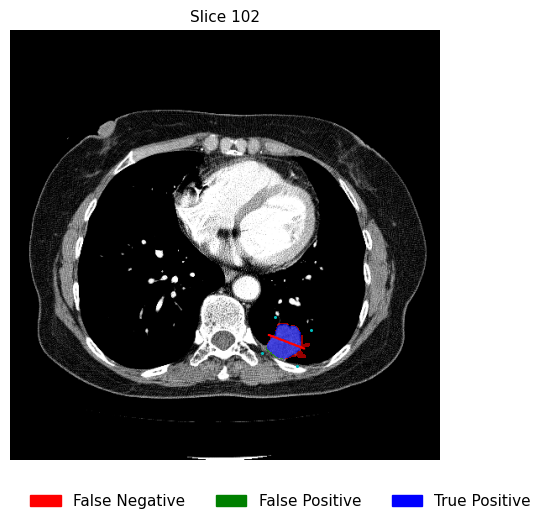

[np.int64(87), np.int64(95), np.int64(103), np.int64(111), np.int64(118)]


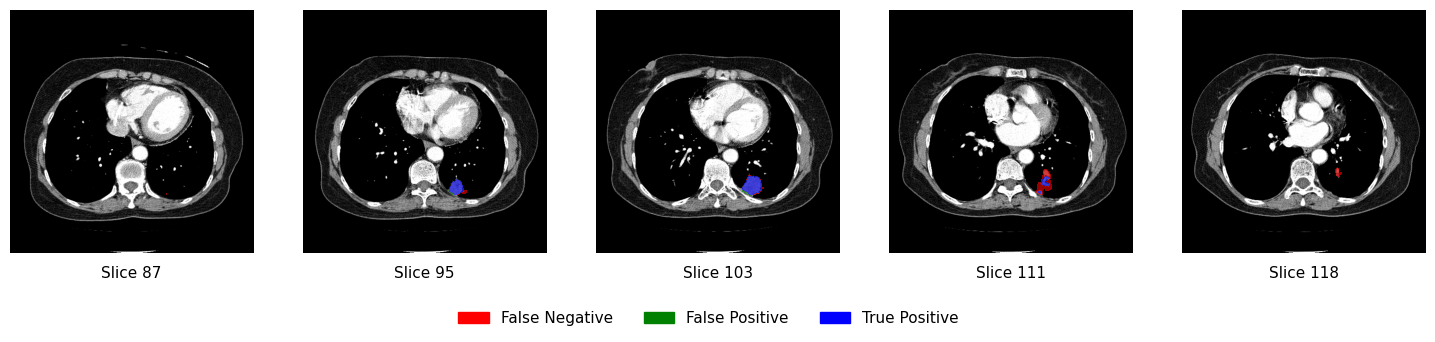

In [ ]:
recist_line = get_line_from_recist(recist_coords = recist_points, slice_number = max_area_slice, img_size = img_arr.shape)
slice_rere, _ = find_first_last_slice(recist_line)

line_data = list(array_to_coords(recist_line[slice_rere]))
x, y = zip(*line_data)

# Add negative points on the corners of the bounding box 
NEGATIVE_PT1 = (negative_points[1], negative_points[0], max_area_slice)
NEGATIVE_PT2 = (negative_points[3], negative_points[2], max_area_slice) 
NEGATIVE_PT3 = (negative_points[5], negative_points[4], max_area_slice)
NEGATIVE_PT4 = (negative_points[7], negative_points[6], max_area_slice) 

session.add_point_interaction(NEGATIVE_PT1, include_interaction=False)
session.add_point_interaction(NEGATIVE_PT2, include_interaction=False)
session.add_point_interaction(NEGATIVE_PT3, include_interaction=False)
session.add_point_interaction(NEGATIVE_PT4, include_interaction=False)

results_xyz = session.target_buffer.clone()
results_zxy = results_xyz.cpu().numpy().transpose(2, 0, 1)

# Repeat visualizations and metric evaluation 
metric_eval1 = Evaluator() 
metric_dict1 = metric_eval1(preds = results_zxy, 
                          targets = mask_arr, 
                          spacing = npz_info['spacing'])

metric_df1 = pd.DataFrame(metric_dict1, index = [0])

print(metric_df1)
# Add masks together so that false negative is 1, false positive is 2, and true positive is 3 
mask_alt = results_zxy * 2 
comb_masks_arr = mask_alt + mask_arr
comb_masks = np.ma.masked_where(comb_masks_arr == 0, comb_masks_arr)

# Plot image and mask with center point prompt
fig = plt.figure()

# Create colour map for mask 
colours = ['red', 'green', 'blue']
boundaries = [1, 2, 3, 4]
cmap = mcolors.ListedColormap(colours)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

# Make legend info 
legend_elem = [mpatches.Patch(color = 'red', label = 'False Negative'), 
               mpatches.Patch(color = 'green', label = 'False Positive'), 
               mpatches.Patch(color = 'blue', label = 'True Positive')]

plt.imshow(np.clip(img[0,:,:,max_area_slice], -135, 215), cmap = 'gray') 
plt.imshow(comb_masks[max_area_slice,:,:], cmap = cmap, norm = norm, interpolation = 'nearest', alpha = 0.6)
plt.scatter(negative_points[0], negative_points[1], c = 'c', marker = '.', s = 6)
plt.scatter(negative_points[2], negative_points[3], c = 'c', marker = '.', s = 6)
plt.scatter(negative_points[4], negative_points[5], c = 'c', marker = '.', s = 6)
plt.scatter(negative_points[6], negative_points[7], c = 'c', marker = '.', s = 6)
plt.plot(x, y, 'r')
plt.axis("off")
plt.title(f"Slice {max_area_slice}", size = 11)
plt.tight_layout()

fig.legend(handles = legend_elem, loc = 'lower right', bbox_to_anchor=(1.0, -0.10), ncol=3, frameon=False, fontsize=11)
plt.show()

pos_neg_true_visual(image = img_arr, 
                    mask_preds = results_zxy, 
                    gt_masks = mask_arr)


Added new point interaction: center 1, scale [[345, 338, 102]]
Took 14.88 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 14.885s
Added new point interaction: center 1, scale [[396, 319, 102]]
Took 14.898 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 14.906s


/home/bhkuser/bhklab/kaitlyn/bhklab-nninteractive/.pixi/envs/default/lib/python3.12/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)


   volume_dice   jaccard  hausdorff  surface_distance  surface_dice  \
0     0.774769  0.632346   6.797911          0.844107      0.943126   

   panoptic_quality  added_path_length  false_negative_volume  \
0               1.0               7155                   9501   

   false_negative_path_length  
0                        6622  


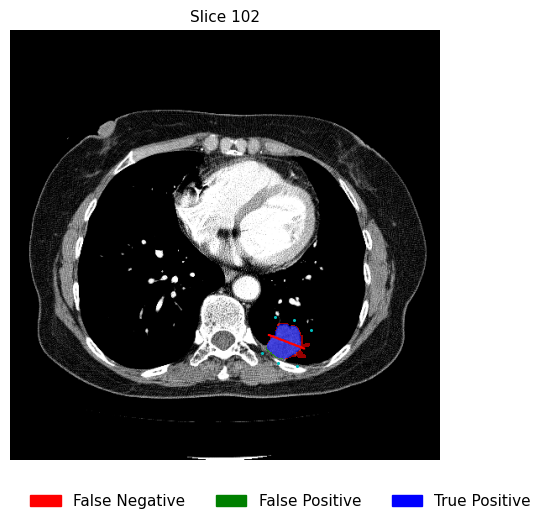

[np.int64(87), np.int64(95), np.int64(103), np.int64(111), np.int64(118)]


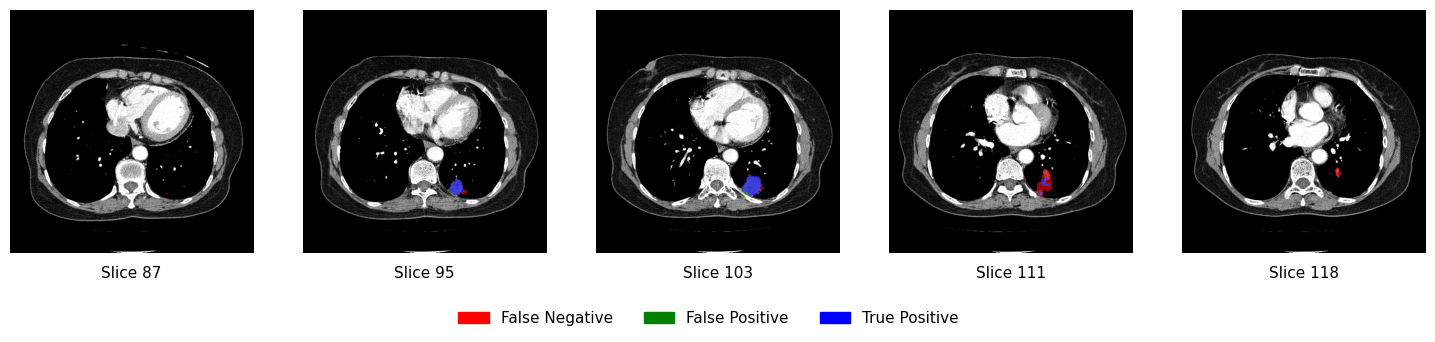

In [ ]:
# Add additional points along the minor axis orientation

NEGATIVE_PT5 = (negative_points[9], negative_points[8], max_area_slice) 
NEGATIVE_PT6 = (negative_points[11], negative_points[10], max_area_slice)

session.add_point_interaction(NEGATIVE_PT5, include_interaction=False)
session.add_point_interaction(NEGATIVE_PT6, include_interaction=False)

results_xyz = session.target_buffer.clone()
results_zxy = results_xyz.cpu().numpy().transpose(2, 0, 1)

# Repeat visualizations and metric evaluation 
metric_eval1 = Evaluator() 
metric_dict1 = metric_eval1(preds = results_zxy, 
                          targets = mask_arr, 
                          spacing = npz_info['spacing'])

metric_df1 = pd.DataFrame(metric_dict1, index = [0])

print(metric_df1)
# Add masks together so that false negative is 1, false positive is 2, and true positive is 3 
mask_alt = results_zxy * 2 
comb_masks_arr = mask_alt + mask_arr
comb_masks = np.ma.masked_where(comb_masks_arr == 0, comb_masks_arr)

# Plot image and mask with center point prompt
fig = plt.figure()

# Create colour map for mask 
colours = ['red', 'green', 'blue']
boundaries = [1, 2, 3, 4]
cmap = mcolors.ListedColormap(colours)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

# Make legend info 
legend_elem = [mpatches.Patch(color = 'red', label = 'False Negative'), 
               mpatches.Patch(color = 'green', label = 'False Positive'), 
               mpatches.Patch(color = 'blue', label = 'True Positive')]

plt.imshow(np.clip(img[0,:,:,max_area_slice], -135, 215), cmap = 'gray') 
plt.imshow(comb_masks[max_area_slice,:,:], cmap = cmap, norm = norm, interpolation = 'nearest', alpha = 0.6)
plt.scatter(negative_points[0], negative_points[1], c = 'c', marker = '.', s = 6)
plt.scatter(negative_points[2], negative_points[3], c = 'c', marker = '.', s = 6)
plt.scatter(negative_points[4], negative_points[5], c = 'c', marker = '.', s = 6)
plt.scatter(negative_points[6], negative_points[7], c = 'c', marker = '.', s = 6)
plt.scatter(negative_points[8], negative_points[9], c = 'c', marker = '.', s = 6)
plt.scatter(negative_points[10], negative_points[11], c = 'c', marker = '.', s = 6)
plt.plot(x, y, 'r')
plt.axis("off")
plt.title(f"Slice {max_area_slice}", size = 11)
plt.tight_layout()

fig.legend(handles = legend_elem, loc = 'lower right', bbox_to_anchor=(1.0, -0.10), ncol=3, frameon=False, fontsize=11)
plt.show()

pos_neg_true_visual(image = img_arr, 
                    mask_preds = results_zxy, 
                    gt_masks = mask_arr)


11
Added new point interaction: center 1, scale [[371, 329, 91]]
Took 14.695 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 14.701s
Added new point interaction: center 1, scale [[371, 329, 113]]
Took 14.217 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 14.224s


/home/bhkuser/bhklab/kaitlyn/bhklab-nninteractive/.pixi/envs/default/lib/python3.12/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)


   volume_dice   jaccard  hausdorff  surface_distance  surface_dice  \
0     0.759426  0.612157    7.08101          0.907683      0.937253   

   panoptic_quality  added_path_length  false_negative_volume  \
0               1.0               7373                  10132   

   false_negative_path_length  
0                        6906  


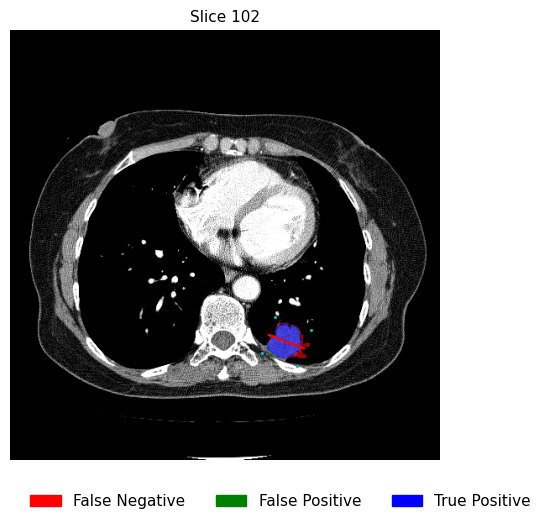

[np.int64(87), np.int64(95), np.int64(103), np.int64(111), np.int64(118)]


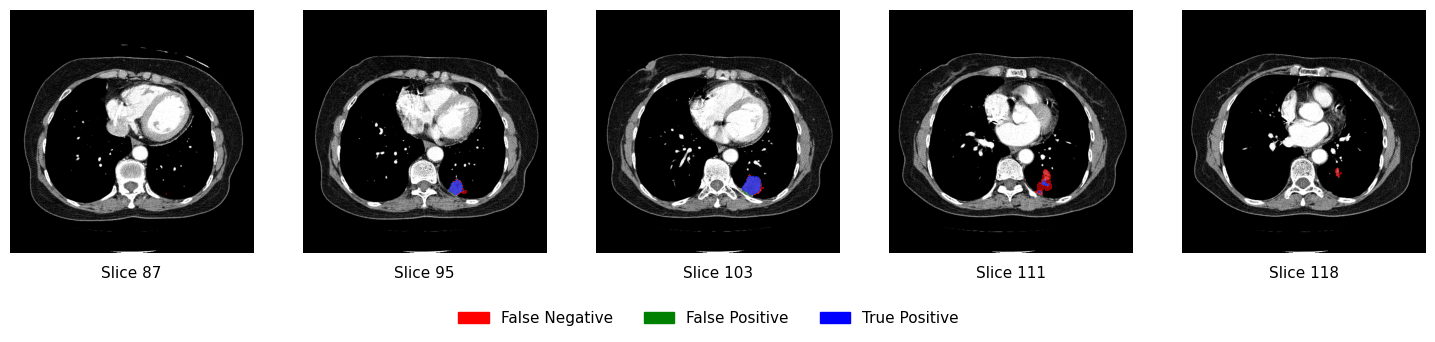

In [ ]:
## Get potential Z-axis boundaries 

# Convert RERECIST line coordinates into physical points to calculate measurement length in mm 
recist_coords = mask2D_to_bbox(gt2D = mask_arr[max_area_slice], 
                               mask_path = 'N/A')
rere_coord1 = (float(recist_coords[0]), float(recist_coords[1]), float(max_area_slice))
rere_coord2 = (float(recist_coords[2]), float(recist_coords[3]), float(max_area_slice))

mask_img = sitk.GetImageFromArray(mask_arr) 
mask_img.SetDirection(npz_info['direction']) 
mask_img.SetOrigin(npz_info['origin']) 
mask_img.SetSpacing(npz_info['spacing'])

rere_phys1 = mask_img.TransformContinuousIndexToPhysicalPoint(rere_coord1) 
rere_phys2 = mask_img.TransformContinuousIndexToPhysicalPoint(rere_coord2) 

recist_len = np.linalg.norm(np.array(rere_phys1) - np.array(rere_phys2)) 

# Calculate the slice indices (with a buffer) where the z-axis exclusion points should be based on half of the length of the RECIST length
slice_dist_from_largest = math.ceil(recist_len / npz_info['spacing'][2] / 2)
print(slice_dist_from_largest)

buffer = 0 #Number of slices to buffer the slice distance by 

NEGATIVE_PT7 = (center_point[1], center_point[0], max_area_slice - slice_dist_from_largest - buffer)
NEGATIVE_PT8 = (center_point[1], center_point[0], max_area_slice + slice_dist_from_largest + buffer)

# Add negative points to the session 
session.add_point_interaction(NEGATIVE_PT7, include_interaction=False)
session.add_point_interaction(NEGATIVE_PT8, include_interaction=False)

results_xyz = session.target_buffer.clone()
results_zxy = results_xyz.cpu().numpy().transpose(2, 0, 1)

# Repeat visualizations and metric evaluation 
metric_eval1 = Evaluator() 
metric_dict1 = metric_eval1(preds = results_zxy, 
                          targets = mask_arr, 
                          spacing = npz_info['spacing'])

metric_df1 = pd.DataFrame(metric_dict1, index = [0])

print(metric_df1)
# Add masks together so that false negative is 1, false positive is 2, and true positive is 3 
mask_alt = results_zxy * 2 
comb_masks_arr = mask_alt + mask_arr
comb_masks = np.ma.masked_where(comb_masks_arr == 0, comb_masks_arr)

# Plot image and mask with center point prompt
fig = plt.figure()

# Create colour map for mask 
colours = ['red', 'green', 'blue']
boundaries = [1, 2, 3, 4]
cmap = mcolors.ListedColormap(colours)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

# Make legend info 
legend_elem = [mpatches.Patch(color = 'red', label = 'False Negative'), 
               mpatches.Patch(color = 'green', label = 'False Positive'), 
               mpatches.Patch(color = 'blue', label = 'True Positive')]

plt.imshow(np.clip(img[0,:,:,max_area_slice], -135, 215), cmap = 'gray') 
plt.imshow(comb_masks[max_area_slice,:,:], cmap = cmap, norm = norm, interpolation = 'nearest', alpha = 0.6)
plt.scatter(negative_points[0], negative_points[1], c = 'c', marker = '.', s = 6)
plt.scatter(negative_points[2], negative_points[3], c = 'c', marker = '.', s = 6)
plt.scatter(negative_points[4], negative_points[5], c = 'c', marker = '.', s = 6)
plt.scatter(negative_points[6], negative_points[7], c = 'c', marker = '.', s = 6)
plt.plot(x, y, 'r')
plt.axis("off")
plt.title(f"Slice {max_area_slice}", size = 11)
plt.tight_layout()

fig.legend(handles = legend_elem, loc = 'lower right', bbox_to_anchor=(1.0, -0.10), ncol=3, frameon=False, fontsize=11)
plt.show()

pos_neg_true_visual(image = img_arr, 
                    mask_preds = results_zxy, 
                    gt_masks = mask_arr) 

In [ ]:
first, last = find_first_last_slice(mask = mask_arr)
print(first, last)
print(NEGATIVE_PT5)

87 118
(np.int64(345), np.int64(338), np.int64(102))
